In [49]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

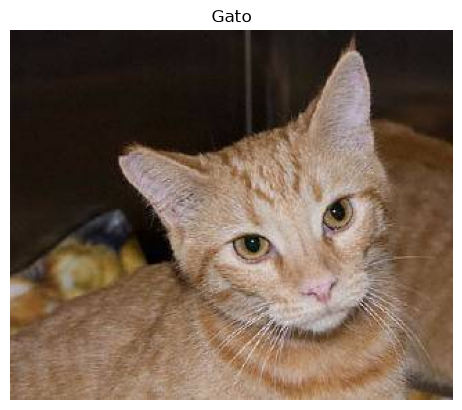

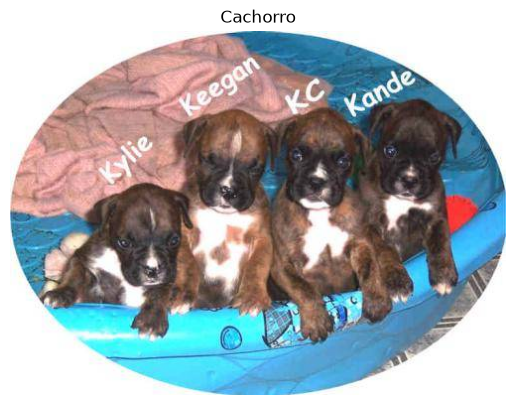

In [50]:
def mostrar_imagem_aleatoria(pasta, label):

    arquivos = os.listdir(pasta)

    escolhido = random.choice(arquivos)

    img = Image.open(os.path.join(pasta, escolhido))

    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
    plt.show()


mostrar_imagem_aleatoria("data/train/cat", "Gato")
mostrar_imagem_aleatoria("data/train/dog", "Cachorro")

In [51]:
def preprocessar_imagem(caminho):

    img = Image.open(caminho)

    img = img.resize((64,64))

    img = img.convert("L")

    img = np.array(img).astype(np.float32) / 255.0

    img = img.flatten()

    return img

In [52]:
def carregar_dados(pasta):

    X = []
    y = []

    # Gatos
    for img_name in os.listdir(os.path.join(pasta, "cat")):

        path = os.path.join(pasta, "cat", img_name)

        X.append(preprocessar_imagem(path))
        y.append(0)

    # Cachorros
    for img_name in os.listdir(os.path.join(pasta, "dog")):

        path = os.path.join(pasta, "dog", img_name)

        X.append(preprocessar_imagem(path))
        y.append(1)

    return np.array(X), np.array(y)

In [53]:
# Carrega cada conjunto separadamente
X_train, y_train = carregar_dados("data/train")
X_val, y_val = carregar_dados("data/validation")
X_test, y_test = carregar_dados("data/test")

# Converte para float32
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

# Normalização
X_train = (X_train - X_train.mean()) / (X_train.std() + 1e-8)
X_val = (X_val - X_val.mean()) / (X_val.std() + 1e-8)
X_test = (X_test - X_test.mean()) / (X_test.std() + 1e-8)

# Embaralha somente o treino
indices = np.random.permutation(len(X_train))

X_train = X_train[indices]
y_train = y_train[indices]

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (300, 4096)
Validação: (100, 4096)
Teste: (100, 4096)


In [54]:
def sigmoid(x):
    return 1/(1+np.exp(-x))


def relu(x):
    return np.maximum(0,x)

In [55]:
# Número de neurônios da camada de entrada
entrada = 4096

# Camada oculta (ajuste equilibrado para melhor generalização)
oculta = 128

# Saída (classificação binária)
saida = 1

np.random.seed(42)

# Inicialização dos pesos (He Initialization)
W1 = np.random.randn(entrada, oculta) * np.sqrt(2 / entrada)
b1 = np.zeros((1, oculta))

W2 = np.random.randn(oculta, saida) * np.sqrt(2 / oculta)
b2 = np.zeros((1, saida))

# Hiperparâmetros
lr = 0.01
epochs = 50

In [56]:
def prever(X):

    Z1 = X @ W1 + b1

    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2

    A2 = sigmoid(Z2)

    return A2

In [57]:
def treinar(X, y):

    global W1, b1, W2, b2

    m = X.shape[0]

    loss_train = []
    loss_val = []

    acc_train = []
    acc_val = []

    # ---------------- EARLY STOPPING ----------------
    melhor_loss = float("inf")
    paciencia = 5
    contador = 0

    for epoch in range(epochs):

        # ---------------- FORWARD ----------------

        Z1 = X @ W1 + b1
        A1 = relu(Z1)

        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        A2 = np.clip(A2, 1e-8, 1 - 1e-8)

        # ---------------- LOSS TREINO ----------------

        loss = -np.mean(
            y.reshape(-1,1) * np.log(A2) +
            (1 - y.reshape(-1,1)) * np.log(1 - A2)
        )

        preds = (A2 > 0.5).astype(int)

        acc = np.mean(preds == y.reshape(-1,1))

        # ---------------- VALIDAÇÃO ----------------

        A2_val = prever(X_val)
        A2_val = np.clip(A2_val, 1e-8, 1 - 1e-8)

        loss_v = -np.mean(
            y_val.reshape(-1,1) * np.log(A2_val) +
            (1 - y_val.reshape(-1,1)) * np.log(1 - A2_val)
        )

        preds_val = (A2_val > 0.5).astype(int)

        acc_v = np.mean(preds_val == y_val.reshape(-1,1))

        # ---------------- ARMAZENAMENTO ----------------

        loss_train.append(loss)
        loss_val.append(loss_v)

        acc_train.append(acc)
        acc_val.append(acc_v)

        print(
            f"Epoch {epoch+1:02d} | "
            f"Loss Train: {loss:.4f} | "
            f"Loss Val: {loss_v:.4f} | "
            f"Acc Train: {acc:.4f} | "
            f"Acc Val: {acc_v:.4f}"
        )

        # ---------------- EARLY STOPPING ----------------

        if loss_v < melhor_loss:
            melhor_loss = loss_v
            contador = 0
        else:
            contador += 1

        if contador >= paciencia:
            print(f"\nEarly Stopping ativado na época {epoch+1}")
            break

        # ---------------- BACKPROP ----------------

        dZ2 = A2 - y.reshape(-1,1)

        dW2 = (A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2 @ W2.T

        dZ1 = dA1 * (Z1 > 0)

        dW1 = (X.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # ---------------- UPDATE ----------------

        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

    return loss_train, loss_val, acc_train, acc_val

In [58]:
loss_train, loss_val, acc_train, acc_val = treinar(
    X_train,
    y_train
)

Epoch 01 | Loss Train: 0.8210 | Loss Val: 0.7874 | Acc Train: 0.5000 | Acc Val: 0.5200
Epoch 02 | Loss Train: 0.7698 | Loss Val: 0.7642 | Acc Train: 0.5000 | Acc Val: 0.5100
Epoch 03 | Loss Train: 0.7326 | Loss Val: 0.7509 | Acc Train: 0.5333 | Acc Val: 0.5200
Epoch 04 | Loss Train: 0.7037 | Loss Val: 0.7419 | Acc Train: 0.5600 | Acc Val: 0.5100
Epoch 05 | Loss Train: 0.6800 | Loss Val: 0.7355 | Acc Train: 0.5933 | Acc Val: 0.5100
Epoch 06 | Loss Train: 0.6601 | Loss Val: 0.7309 | Acc Train: 0.6233 | Acc Val: 0.5300
Epoch 07 | Loss Train: 0.6424 | Loss Val: 0.7277 | Acc Train: 0.6533 | Acc Val: 0.5200
Epoch 08 | Loss Train: 0.6265 | Loss Val: 0.7255 | Acc Train: 0.6500 | Acc Val: 0.5300
Epoch 09 | Loss Train: 0.6121 | Loss Val: 0.7243 | Acc Train: 0.6733 | Acc Val: 0.5400
Epoch 10 | Loss Train: 0.5989 | Loss Val: 0.7232 | Acc Train: 0.6767 | Acc Val: 0.5300
Epoch 11 | Loss Train: 0.5866 | Loss Val: 0.7229 | Acc Train: 0.6967 | Acc Val: 0.5400
Epoch 12 | Loss Train: 0.5750 | Loss Val: 0

In [59]:
A2_test = prever(X_test)

A2_test = np.clip(A2_test, 1e-8, 1 - 1e-8)

preds_test = (A2_test > 0.5).astype(int)

acc_test = np.mean(preds_test == y_test.reshape(-1,1))

loss_test = -np.mean(
    y_test.reshape(-1,1) * np.log(A2_test) +
    (1 - y_test.reshape(-1,1)) * np.log(1 - A2_test)
)

acertos = np.sum(preds_test.flatten() == y_test)
total = len(y_test)

print("\n========== TESTE FINAL (ETAPA 1) ==========")
print(f"Total de imagens: {total}")
print(f"Acertos: {acertos}")
print(f"Erros: {total - acertos}")
print(f"Acurácia: {acc_test*100:.2f}%")
print(f"Loss: {loss_test:.4f}")


========== TESTE FINAL (ETAPA 1) ==========
Total de imagens: 100
Acertos: 54
Erros: 46
Acurácia: 54.00%
Loss: 0.7210


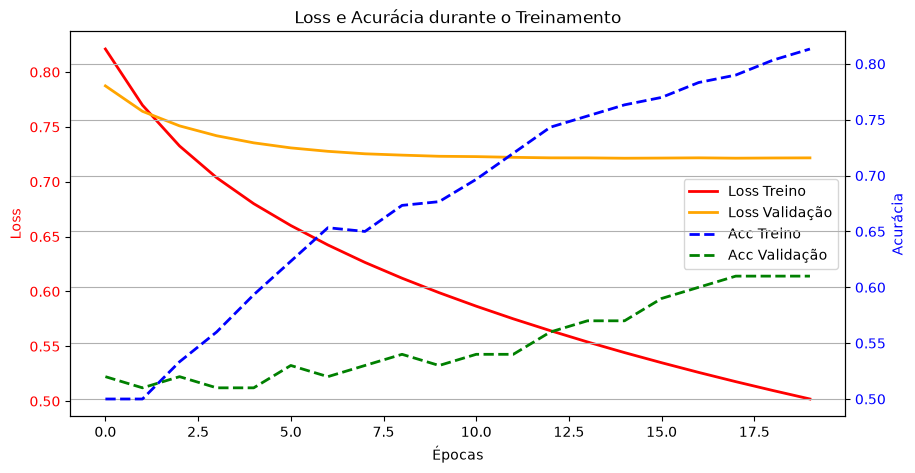

In [60]:
fig, ax1 = plt.subplots(figsize=(10,5))

# LOSS
ax1.plot(loss_train, label="Loss Treino", color="red", linewidth=2)
ax1.plot(loss_val, label="Loss Validação", color="orange", linewidth=2)

ax1.set_xlabel("Épocas")
ax1.set_ylabel("Loss", color="red")
ax1.tick_params(axis="y", labelcolor="red")

# ACURÁCIA
ax2 = ax1.twinx()

ax2.plot(acc_train, label="Acc Treino", color="blue", linestyle="--", linewidth=2)
ax2.plot(acc_val, label="Acc Validação", color="green", linestyle="--", linewidth=2)

ax2.set_ylabel("Acurácia", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

# Legenda
linhas1, labels1 = ax1.get_legend_handles_labels()
linhas2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(linhas1 + linhas2,
           labels1 + labels2,
           loc="center right")

plt.title("Loss e Acurácia durante o Treinamento")
plt.grid(True)

plt.show()